# FC Match Analysis - Exploratory Data Analysis (SQL)

In [187]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import json
import pandas as pd

conn = sqlite3.connect("../data/fc_matches.db")

for table in ["matches", "match_details", "players"]:
    count = pd.read_sql(f"SELECT COUNT(*) AS n FROM {table}", conn)
    print(f"{table}: {count['n'][0]:,} rows")

# print(pd.read_sql("SELECT * FROM matches LIMIT 1", conn).columns.tolist())
# print(pd.read_sql("SELECT * FROM match_details LIMIT 1", conn).columns.tolist())
# print(pd.read_sql("SELECT * FROM players LIMIT 1", conn).columns.tolist())

matches: 7,841 rows
match_details: 15,682 rows
players: 282,276 rows


## Load Metadata Lookups

In [188]:
# load season metadata
with open("../data/metadata/season_ids.json", "r", encoding="utf-8") as f:
    season_meta = json.load(f)

# create lookup: season_id → className
season_map = {s["seasonId"]: s["className"] for s in season_meta}

# load position metadata
with open("../data/metadata/sppositions.json", "r", encoding="utf-8") as f:
    position_meta = json.load(f)

# create lookup: spposition → desc
position_map = {p["spposition"]: p["desc"] for p in position_meta}

print(f"Season map loaded: {len(season_map)} seasons")
print(f"Position map loaded: {len(position_map)} positions")

# print(f"\nSeason 850 → {season_map.get(850)}")
# print(f"Season 831 → {season_map.get(831)}")

Season map loaded: 144 seasons
Position map loaded: 29 positions


## Data Overview


In [189]:
# date range
date_range = pd.read_sql("""
    SELECT 
        MIN(match_date) AS first_match,
        MAX(match_date) AS last_match,
        COUNT(*) AS total_matches
    FROM matches
""", conn)
print("Date Range:")
print(f"First match:    {date_range['first_match'][0]}")
print(f"Last match:     {date_range['last_match'][0]}")

Date Range:
First match:    2025-11-28T01:51:35
Last match:     2025-11-28T03:00:00


In [190]:
# result distribution
results = pd.read_sql("""
    SELECT 
        result,
        COUNT(*) AS count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM match_details
    WHERE (match_id, ouid) IN (
        SELECT match_id, MIN(ouid)
        FROM match_details
        GROUP BY match_id
    )
    GROUP BY result
    ORDER BY count DESC
""", conn)

print("Result Distribution:")
for _, row in results.iterrows():
    print(f"  {row['result']:<6}: {row['count']:,} ({row['pct']}%)")

# plt.figure()
# plt.pie(
#     results["count"],
#     labels=results["result"],
#     colors=["red", "green", "blue"],
#     autopct="%1.1f%%",
#     startangle=90
# )
# plt.title("Match Result Distribution:")
# plt.show()

Result Distribution:
  loss  : 3,177 (40.5%)
  win   : 3,176 (40.5%)
  draw  : 1,488 (19.0%)


In [191]:
# unique player_ids
unique_players = pd.read_sql("""
    SELECT COUNT(DISTINCT player_id) AS unique_players
    FROM players
""", conn)

# unique season_ids
unique_seasons = pd.read_sql("""
    SELECT COUNT(DISTINCT season_prefix) AS unique_seasons
    FROM players
""", conn)

print(f"Unique players in players table: {unique_players['unique_players'][0]:,}")
print(f"Unique seasons in players table: {unique_seasons['unique_seasons'][0]}")

Unique players in players table: 7,018
Unique seasons in players table: 139


In [192]:
# sp_position distribution
position_dist = pd.read_sql("""
    SELECT 
        sp_position,
        COUNT(*) AS total_players
    FROM players
    GROUP BY sp_position
    ORDER BY sp_position
""", conn)

# add position names
position_dist["position_name"] = position_dist["sp_position"].map(
    lambda x: position_map.get(x, str(x))
)

print("Position distribution (all players):")
print(position_dist[["position_name", "total_players"]].to_string(index=False))
print(f"\nNote: SUB = started on bench, some may have played as substitutes")
print(f"\nTotal: {position_dist['total_players'].sum():,}")

Position distribution (all players):
position_name  total_players
           GK          15682
           SW            115
          RWB           3471
           RB          11700
          RCB          15631
           CB            888
          LCB          15638
           LB          11762
          LWB           3386
          RDM          10168
          CDM           2942
          LDM           9996
           RM           4778
          RCM           4003
           CM            865
          LCM           4234
           LM           4751
          RAM           6414
          CAM           9621
          LAM           6352
           RF           1058
           CF           1750
           LF            649
           RW           4787
           RS           2594
           ST          11426
           LS           3010
           LW           4831
          SUB         109774

Note: SUB = started on bench, some may have played as substitutes

Total: 282,276


In [193]:
# sp_grade distribution
grade_dist = pd.read_sql("""
    SELECT 
        sp_grade,
        COUNT(*) AS total,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM players
    GROUP BY sp_grade
    ORDER BY sp_grade
""", conn)

print(grade_dist.to_string(index=False))
print(f"\nTotal: {grade_dist['total'].sum():,}")
print(f"\nMost common grade: {grade_dist.loc[grade_dist['total'].idxmax(), 'sp_grade']} ({grade_dist['total'].max():,} players, {grade_dist.loc[grade_dist['total'].idxmax(), 'pct']}%)")

 sp_grade  total  pct
        0  14077  5.0
        1  27765  9.8
        2   6521  2.3
        3   5051  1.8
        4   3755  1.3
        5  25928  9.2
        6  20006  7.1
        7  19324  6.8
        8 145389 51.5
        9   8405  3.0
       10   2865  1.0
       11   1029  0.4
       12    548  0.2
       13   1613  0.6

Total: 282,276

Most common grade: 8 (145,389 players, 51.5%)


In [194]:
# player appearances by season
season_dist = pd.read_sql("""
    SELECT 
        season_prefix,
        COUNT(*) AS total_players
    FROM players
    GROUP BY season_prefix
    ORDER BY total_players DESC
""", conn)
season_dist = pd.read_sql("""
    SELECT 
        season_prefix,
        COUNT(*) AS total_players
    FROM players
    GROUP BY season_prefix
    ORDER BY total_players DESC
""", conn)

season_dist["season_name"] = season_dist["season_prefix"].map(
    lambda x: season_map.get(x, str(x))
)

print(f"Total unique seasons: {len(season_dist)}")
print(season_dist[["season_prefix", "season_name", "total_players"]].to_string(index=False))

Total unique seasons: 139
 season_prefix                                season_name  total_players
           300                          25 LIVE (25 LIVE)          25968
           825                   CU (Champions of Europe)          19118
           834          24 UCL (24 UEFA Champions League)          17612
           829                  GRU (Greatest Runner-Ups)          14665
           836                            WB (Wonderboys)          11910
           814                   UT (Unexpected Transfer)          11366
           826               24EP (2024 Energetic Player)          11339
           840                      LE (Legend of Europa)          11142
           802                                DC (Decade)          10720
           844            25 TOTS (25 Team Of The Season)           9415
           289                           CC (CenturyClub)           7759
           827                          BDO (Ballon d'Or)           7031
           291           

In [195]:
# overall shooting rate from players
overall_shoot_rate = pd.read_sql("""
    SELECT 
        COUNT(*) AS total_shoot,
        SUM(CASE WHEN shoot > 0 THEN 1 ELSE 0 END) AS shoot,
        SUM(CASE WHEN shoot = 0 THEN 1 ELSE 0 END) AS no_shoot,
        ROUND(SUM(CASE WHEN shoot > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS rate
    FROM players
""", conn)

print("Overall shooting rate (all positions):")
print(overall_shoot_rate.to_string(index=False))

Overall shooting rate (all positions):
 total_shoot  shoot  no_shoot  rate
      282276  63888    218388  22.6


In [196]:
# shoot_details from shoot_details
shoot_details_check = pd.read_sql("""
    SELECT COUNT(*) AS total_shoots,
           SUM(CASE WHEN result = 3 THEN 1 ELSE 0 END) AS goals,
           SUM(CASE WHEN result = 1 THEN 1 ELSE 0 END) AS on_target,
           SUM(CASE WHEN result = 2 THEN 1 ELSE 0 END) AS off_target,
           SUM(CASE WHEN in_penalty = 1 THEN 1 ELSE 0 END) AS in_penalty_box,
           SUM(CASE WHEN assist = 1 THEN 1 ELSE 0 END) AS assisted
    FROM shoot_details
""", conn)

print(shoot_details_check.to_string(index=False))

 total_shoots  goals  on_target  off_target  in_penalty_box  assisted
       119838  37206      49666       32966           78025    104116


In [197]:
# shoot type distribution
TYPE_MAP = {
    1: "normal", 2: "finesse", 3: "header", 4: "lob",
    5: "flare", 6: "low", 7: "volley", 8: "free-kick",
    9: "penalty", 10: "KNUCKLE", 11: "BICYCLE", 12: "super"
}

shoot_types = pd.read_sql("""
    SELECT 
        type,
        COUNT(*) AS count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM shoot_details
    GROUP BY type
    ORDER BY type
""", conn)

shoot_types["type_name"] = shoot_types["type"].map(lambda x: TYPE_MAP.get(x, "Unknown"))

print("Shoot type distribution:")
print(shoot_types[["type", "type_name", "count", "pct"]].to_string(index=False))
print(f"\nTypes outside 1-12: {shoot_types[~shoot_types['type'].between(1, 12)]['type'].tolist()}")

Shoot type distribution:
 type type_name  count  pct
    1    normal  22759 19.0
    2   finesse  49700 41.5
    3    header  19445 16.2
    4       lob    631  0.5
    6       low  11586  9.7
    7    volley   6067  5.1
    8 free-kick   2706  2.3
    9   penalty   1071  0.9
   10   KNUCKLE   1045  0.9
   12     super   2548  2.1
   13   Unknown   2280  1.9

Types outside 1-12: [13]


In [198]:
# check goaltotal and goaldisplay
check = pd.read_sql("""
    SELECT 
        md.match_id,
        md.ouid,
        md.goal_total,
        md.goal_total_display,
        SUM(p.goal) AS player_goals_sum
    FROM match_details md
    JOIN players p 
        ON md.match_id = p.match_id 
        AND md.ouid = p.ouid
    GROUP BY md.match_id, md.ouid
""", conn)

check["matches_total"] = check["goal_total"] == check["player_goals_sum"]
check["matches_display"] = check["goal_total_display"] == check["player_goals_sum"]

print(f"Total sides: {len(check):,}")
print(f"\nplayer goals sum == goal_total:           {check['matches_total'].sum():,} ({check['matches_total'].mean()*100:.1f}%)")
print(f"player goals sum == goal_total_display:     {check['matches_display'].sum():,} ({check['matches_display'].mean()*100:.1f}%)")

mismatches = check[~check["matches_total"]]
print(f"\nMismatches with goal_total: {len(mismatches)}")

Total sides: 15,682

player goals sum == goal_total:           15,682 (100.0%)
player goals sum == goal_total_display:     15,406 (98.2%)

Mismatches with goal_total: 0


## Match Overview

In [199]:
# average goal per match
total_goals = pd.read_sql("""
    SELECT 
        SUM(goal_total_display) AS total_goals,
        COUNT(DISTINCT match_id) AS total_matches,
        ROUND(SUM(goal_total_display) * 1.0 / COUNT(DISTINCT match_id), 2) AS avg_goals_per_match
    FROM match_details
""", conn)

print("Overall Goal Stats:")
print(f"Total goals scored:    {total_goals['total_goals'][0]:,}")
print(f"Total matches:         {total_goals['total_matches'][0]:,}")
print(f"Avg goals for matches: {total_goals['avg_goals_per_match'][0]}")

Overall Goal Stats:
Total goals scored:    37,491
Total matches:         7,841
Avg goals for matches: 4.78


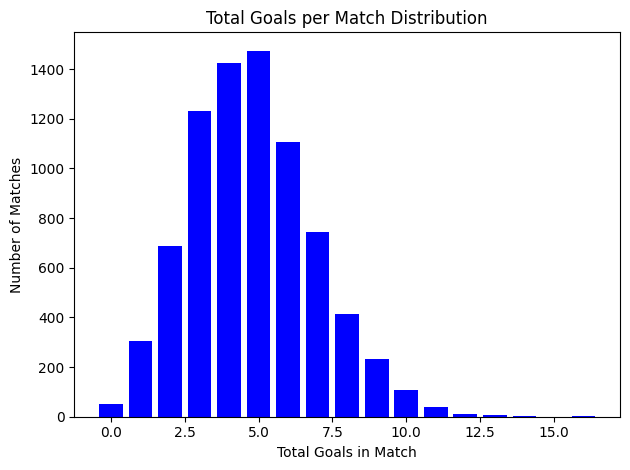

In [200]:
# goal distribution
goal_dist = pd.read_sql("""
    SELECT 
        total_goals,
        COUNT(*) AS matches,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM (
        SELECT 
            match_id,
            SUM(goal_total_display) AS total_goals
        FROM match_details
        GROUP BY match_id
    )
    GROUP BY total_goals
    ORDER BY total_goals
""", conn)

# print("Goals per Match Distribution:")
# print(goal_dist.to_string(index=False))

plt.figure()
plt.bar(goal_dist["total_goals"], goal_dist["matches"], color="blue")
plt.title("Total Goals per Match Distribution")
plt.xlabel("Total Goals in Match")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()

Goals by Match Result:
result  count  total_goals  avg_goals  avg_shots
   win   6353        21563      3.394      8.641
  draw   2976         6434      2.162      7.263
  loss   6353         9494      1.494      6.504


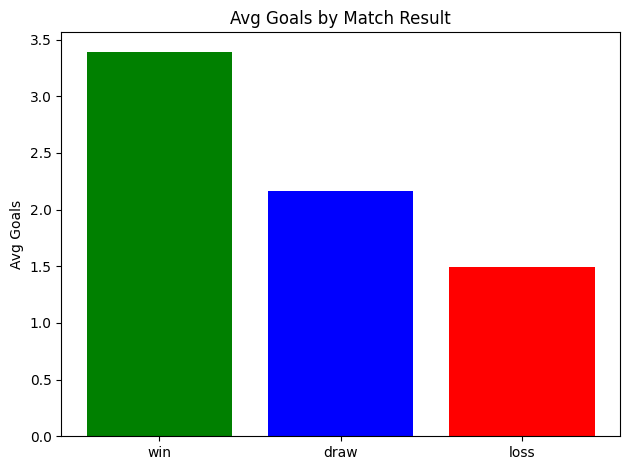

In [201]:
# average goals by result
goals_by_result = pd.read_sql("""
    SELECT 
        result,
        COUNT(*) AS count,
        SUM(goal_total_display) AS total_goals,
        ROUND(AVG(goal_total_display), 3) AS avg_goals,
        ROUND(AVG(shoot_total), 3) AS avg_shots
    FROM match_details
    GROUP BY result
    ORDER BY avg_goals DESC
""", conn)

print("Goals by Match Result:")
print(goals_by_result.to_string(index=False))

plt.figure()
colors = {"win": "green", "loss": "red", "draw": "blue"}
plt.bar(
    goals_by_result["result"],
    goals_by_result["avg_goals"],
    color=[colors[r] for r in goals_by_result["result"]]
)
plt.title("Avg Goals by Match Result")
plt.ylabel("Avg Goals")
plt.tight_layout()
plt.show()

## spPosition and spGrade Analysis - Win/Loss/Draw

In [202]:
# create reusable view with position groups
conn.execute("""
    CREATE VIEW IF NOT EXISTS players_position AS
    SELECT 
        p.*,
        CASE 
            WHEN p.sp_position = 0 THEN 'GK'
            WHEN p.sp_position BETWEEN 1 AND 8 THEN 'Defender'
            WHEN p.sp_position BETWEEN 9 AND 19 THEN 'Midfielder'
            WHEN p.sp_position BETWEEN 20 AND 27 THEN 'Attacker'
            ELSE 'Bench'
        END AS position_group
    FROM players p
""")
conn.commit()
print("View created: players_position")

View created: players_position


In [203]:
# shoot, effective shoot, goal total and rate by position group and match result
position_result_stats = pd.read_sql("""
    SELECT 
        p.position_group AS position,
        md.result,
        COUNT(*) AS total,
        SUM(CASE WHEN p.shoot > 0 THEN 1 ELSE 0 END) AS shoot,
        SUM(CASE WHEN p.effective_shoot > 0 THEN 1 ELSE 0 END) AS effective_shoot,
        SUM(CASE WHEN p.goal > 0 THEN 1 ELSE 0 END) AS goal,
        ROUND(SUM(CASE WHEN p.shoot > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS shoot_rate,
        ROUND(SUM(CASE WHEN p.effective_shoot > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS effective_rate,
        ROUND(SUM(CASE WHEN p.goal > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS goal_rate,
        ROUND(SUM(p.goal) * 1.0 / NULLIF(SUM(p.shoot), 0), 3) AS conversion_rate
    FROM players_view p
    JOIN match_details md
        ON p.match_id = md.match_id
        AND p.ouid = md.ouid
    GROUP BY position, md.result
    ORDER BY position, md.result
""", conn)

print(position_result_stats.to_string(index=False))

  position result  total  shoot  effective_shoot  goal  shoot_rate  effective_rate  goal_rate  conversion_rate
  Attacker   draw   5738   4291             3798  2451        74.8            66.2       42.7            0.340
  Attacker   loss  12505   8952             7605  4011        71.6            60.8       32.1            0.266
  Attacker    win  11862   9676             8935  6818        81.6            75.3       57.5            0.432
     Bench   draw  20832    270              217   106         1.3             1.0        0.5            0.279
     Bench   loss  44471    603              460   178         1.4             1.0        0.4            0.214
     Bench    win  44471    532              444   271         1.2             1.0        0.6            0.376
  Defender   draw  11869   1124              668   255         9.5             5.6        2.1            0.202
  Defender   loss  25329   2120             1196   355         8.4             4.7        1.4            0.148
 

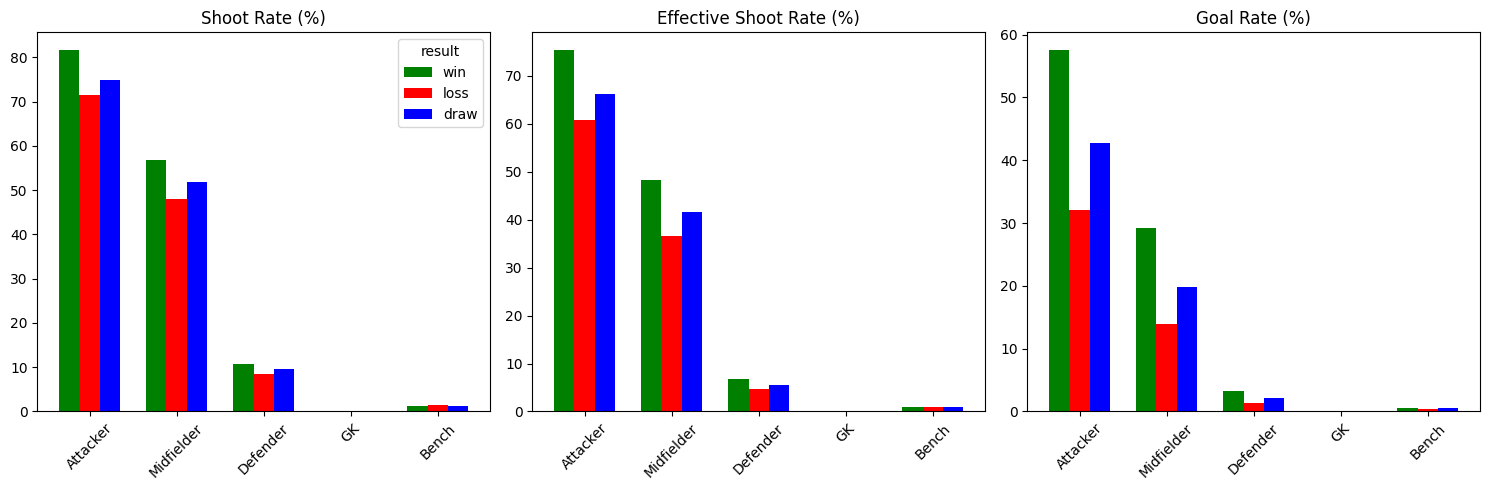

In [204]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ["shoot_rate", "effective_rate", "goal_rate"]
titles = ["Shoot Rate (%)", "Effective Shoot Rate (%)", "Goal Rate (%)"]
colors = {"win": "green", "loss": "red", "draw": "blue"}
positions = ["Attacker", "Midfielder", "Defender", "GK", "Bench"]

for ax, metric, title in zip(axes, metrics, titles):
    pivoted = position_result_stats.pivot_table(
        index="position", columns="result", values=metric
    ).reindex(positions)
    
    pivoted[["win", "loss", "draw"]].plot(
        kind="bar", ax=ax, color=["green", "red", "blue"],
        width=0.7, legend=(ax == axes[0])
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_xticklabels(positions, rotation=45)

plt.tight_layout()
plt.show()

In [205]:
# shoot, effective shoot, goal total and rate by sp_grade and match result
grade_result_stats = pd.read_sql("""
    SELECT 
        p.sp_grade,
        md.result,
        COUNT(*) AS total,
        SUM(CASE WHEN p.shoot > 0 THEN 1 ELSE 0 END) AS shoot,
        SUM(CASE WHEN p.effective_shoot > 0 THEN 1 ELSE 0 END) AS effective_shoot,
        SUM(CASE WHEN p.goal > 0 THEN 1 ELSE 0 END) AS goal,
        ROUND(SUM(CASE WHEN p.shoot > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS shoot_rate,
        ROUND(SUM(CASE WHEN p.effective_shoot > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS effective_rate,
        ROUND(SUM(CASE WHEN p.goal > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS goal_rate
    FROM players p
    JOIN match_details md
        ON p.match_id = md.match_id
        AND p.ouid = md.ouid
    GROUP BY p.sp_grade, md.result
    ORDER BY p.sp_grade,
        CASE md.result
            WHEN 'win' THEN 1
            WHEN 'loss' THEN 2
            ELSE 3
        END
""", conn)

# print(grade_result_stats.to_string(index=False))

In [206]:
# shoot, effective shoot, goal total and rate by sp_grade and match result - ATTACKERS only
attacker_grade_result_stats = pd.read_sql("""
    SELECT 
        p.sp_grade,
        md.result,
        COUNT(*) AS total,
        SUM(CASE WHEN p.shoot > 0 THEN 1 ELSE 0 END) AS shoot,
        SUM(CASE WHEN p.effective_shoot > 0 THEN 1 ELSE 0 END) AS effective_shoot,
        SUM(CASE WHEN p.goal > 0 THEN 1 ELSE 0 END) AS goal,
        ROUND(SUM(CASE WHEN p.shoot > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS shoot_rate,
        ROUND(SUM(CASE WHEN p.effective_shoot > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS effective_rate,
        ROUND(SUM(CASE WHEN p.goal > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS goal_rate
    FROM players p
    JOIN match_details md
        ON p.match_id = md.match_id
        AND p.ouid = md.ouid
    WHERE p.sp_position BETWEEN 20 AND 27
    GROUP BY p.sp_grade, md.result
    ORDER BY p.sp_grade,
        CASE md.result
            WHEN 'win' THEN 1
            WHEN 'loss' THEN 2
            ELSE 3
        END
""", conn)

# print(attacker_grade_result_stats.to_string(index=False))

In [207]:
# shoot, effective shoot, goal total and rate by sp_grade and match result - MIDFIELDERS only
midfielder_grade_result_stats = pd.read_sql("""
    SELECT 
        p.sp_grade,
        md.result,
        COUNT(*) AS total,
        SUM(CASE WHEN p.shoot > 0 THEN 1 ELSE 0 END) AS shoot,
        SUM(CASE WHEN p.effective_shoot > 0 THEN 1 ELSE 0 END) AS effective_shoot,
        SUM(CASE WHEN p.goal > 0 THEN 1 ELSE 0 END) AS goal,
        ROUND(SUM(CASE WHEN p.shoot > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS shoot_rate,
        ROUND(SUM(CASE WHEN p.effective_shoot > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS effective_rate,
        ROUND(SUM(CASE WHEN p.goal > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS goal_rate
    FROM players p
    JOIN match_details md
        ON p.match_id = md.match_id
        AND p.ouid = md.ouid
    WHERE p.sp_position BETWEEN 9 AND 19
    GROUP BY p.sp_grade, md.result
    ORDER BY p.sp_grade,
        CASE md.result
            WHEN 'win' THEN 1
            WHEN 'loss' THEN 2
            ELSE 3
        END
""", conn)

# print(midfielder_grade_result_stats.to_string(index=False))

In [208]:
# shoot, effective shoot, goal total and rate by sp_grade and match result - DEFENDERS only
defender_grade_result_stats = pd.read_sql("""
    SELECT 
        p.sp_grade,
        md.result,
        COUNT(*) AS total,
        SUM(CASE WHEN p.shoot > 0 THEN 1 ELSE 0 END) AS shoot,
        SUM(CASE WHEN p.effective_shoot > 0 THEN 1 ELSE 0 END) AS effective_shoot,
        SUM(CASE WHEN p.goal > 0 THEN 1 ELSE 0 END) AS goal,
        ROUND(SUM(CASE WHEN p.shoot > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS shoot_rate,
        ROUND(SUM(CASE WHEN p.effective_shoot > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS effective_rate,
        ROUND(SUM(CASE WHEN p.goal > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS goal_rate
    FROM players p
    JOIN match_details md
        ON p.match_id = md.match_id
        AND p.ouid = md.ouid
    WHERE p.sp_position BETWEEN 1 AND 8
    GROUP BY p.sp_grade, md.result
    ORDER BY p.sp_grade,
        CASE md.result
            WHEN 'win' THEN 1
            WHEN 'loss' THEN 2
            ELSE 3
        END
""", conn)

# print(defender_grade_result_stats.to_string(index=False))

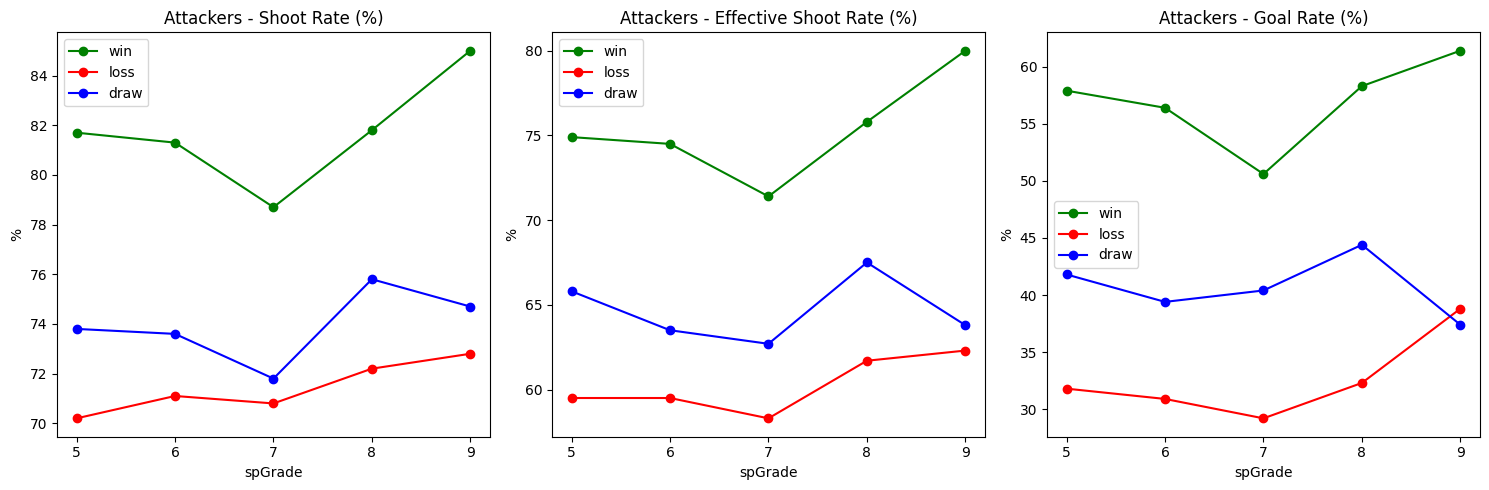

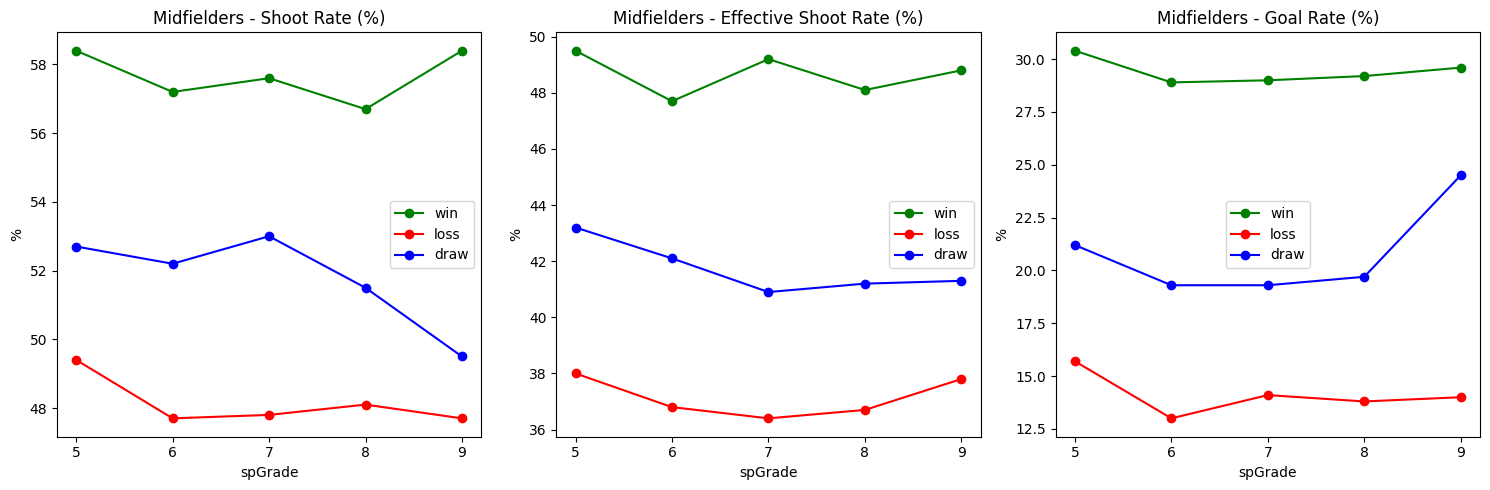

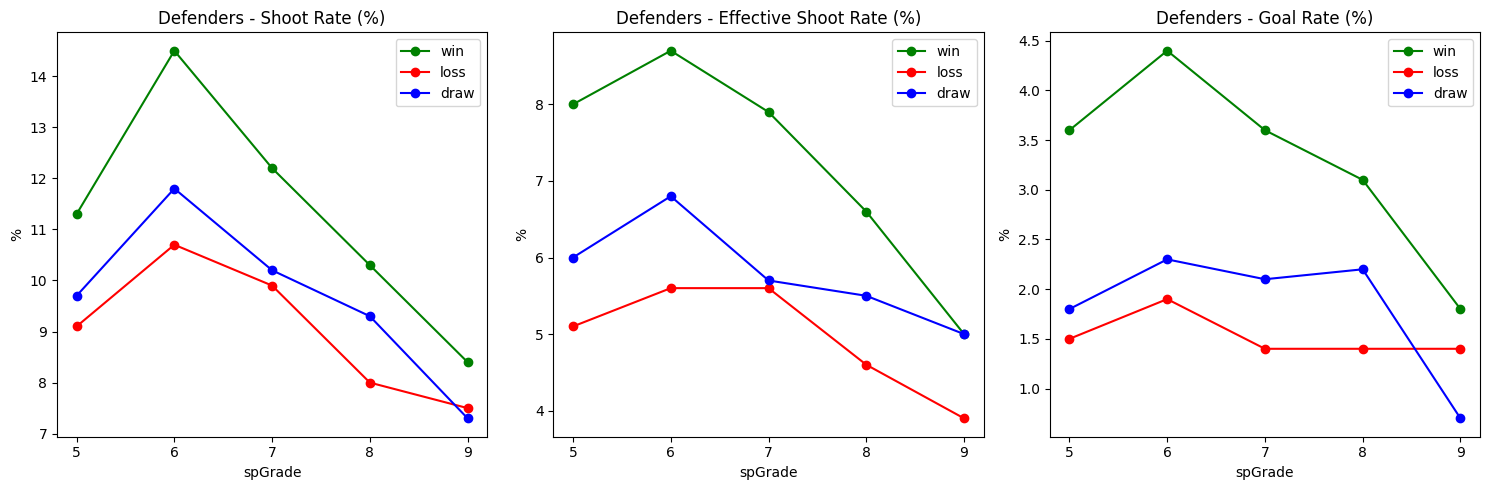

In [209]:
# filter to grade 5-9 for cleaner visualization
for df_name, df, position in [
    ("attacker", attacker_grade_result_stats, "Attackers"),
    ("midfielder", midfielder_grade_result_stats, "Midfielders"),
    ("defender", defender_grade_result_stats, "Defenders")
]:
    filtered = df[df["sp_grade"].between(5, 9)]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, metric, title in zip(axes, 
                                  ["shoot_rate", "effective_rate", "goal_rate"],
                                  ["Shoot Rate (%)", "Effective Shoot Rate (%)", "Goal Rate (%)"]):
        for result in ["win", "loss", "draw"]:
            subset = filtered[filtered["result"] == result]
            ax.plot(subset["sp_grade"], subset[metric],
                    marker="o", label=result, color={"win":"green","loss":"red","draw":"blue"}[result])
        ax.set_title(f"{position} - {title}")
        ax.set_xlabel("spGrade")
        ax.set_ylabel("%")
        ax.legend()
        ax.set_xticks(range(5, 10))
    plt.tight_layout()
    plt.show()

- spGrade alone doesn't determine match outcomes

- shoot rates are similar across win/loss at every grade
- win/loss goal rate gap exists at every grade level
    - grade 5 winners score just as much more than grade 5 losers 
    - as grade 8 winners score more than grade 8 losers
- gap is driven by position, not grade
    - attackers:        win 57%  vs loss 31% goal rate
    - midfieldsers:     win 30%  vs loss 14% goal rate
    - defenders:        win 3.5% vs loss 1.5% goal rate

## Season Analysis

In [210]:
# conversion rate by season for ATTACKERS only
attacker_season_stats = pd.read_sql("""
    SELECT 
        p.season_prefix,
        COUNT(*) AS total,
        SUM(p.goal) AS total_goals,
        SUM(p.shoot) AS total_shoots,
        ROUND(SUM(p.goal) * 1.0 / NULLIF(SUM(p.shoot), 0), 3) AS conversion_rate
    FROM players_view p
    WHERE p.position_group = 'Attacker'
    AND p.shoot > 0
    GROUP BY p.season_prefix
    HAVING total >= 50                                
    ORDER BY conversion_rate DESC
""", conn)

attacker_season_stats["season_name"] = attacker_season_stats["season_prefix"].map(
    lambda x: season_map.get(x, str(x))
)

print(f"Total seasons with ATTACKER data: {len(attacker_season_stats)}")
print(attacker_season_stats[["season_prefix", "season_name", "total", 
                              "total_goals", "total_shoots", "conversion_rate"]].to_string(index=False))

Total seasons with ATTACKER data: 39
 season_prefix                                season_name  total  total_goals  total_shoots  conversion_rate
           801                  JVA (Juventus Ambassador)     71           54           128            0.422
           100                  ICON TM (ICON The Moment)    313          326           828            0.394
           830                    24KB (24 K-League Best)    271          234           602            0.389
           835                           25HR (25 Heroes)    193          190           490            0.388
           826               24EP (2024 Energetic Player)   1263         1028          2656            0.387
           831              25 TOTY (25 Team Of The Year)    366          325           843            0.386
           850       25FSL (25 FCO Superchampions League)    188          183           477            0.384
           852       FAC (Football Association Champions)    174          166           437

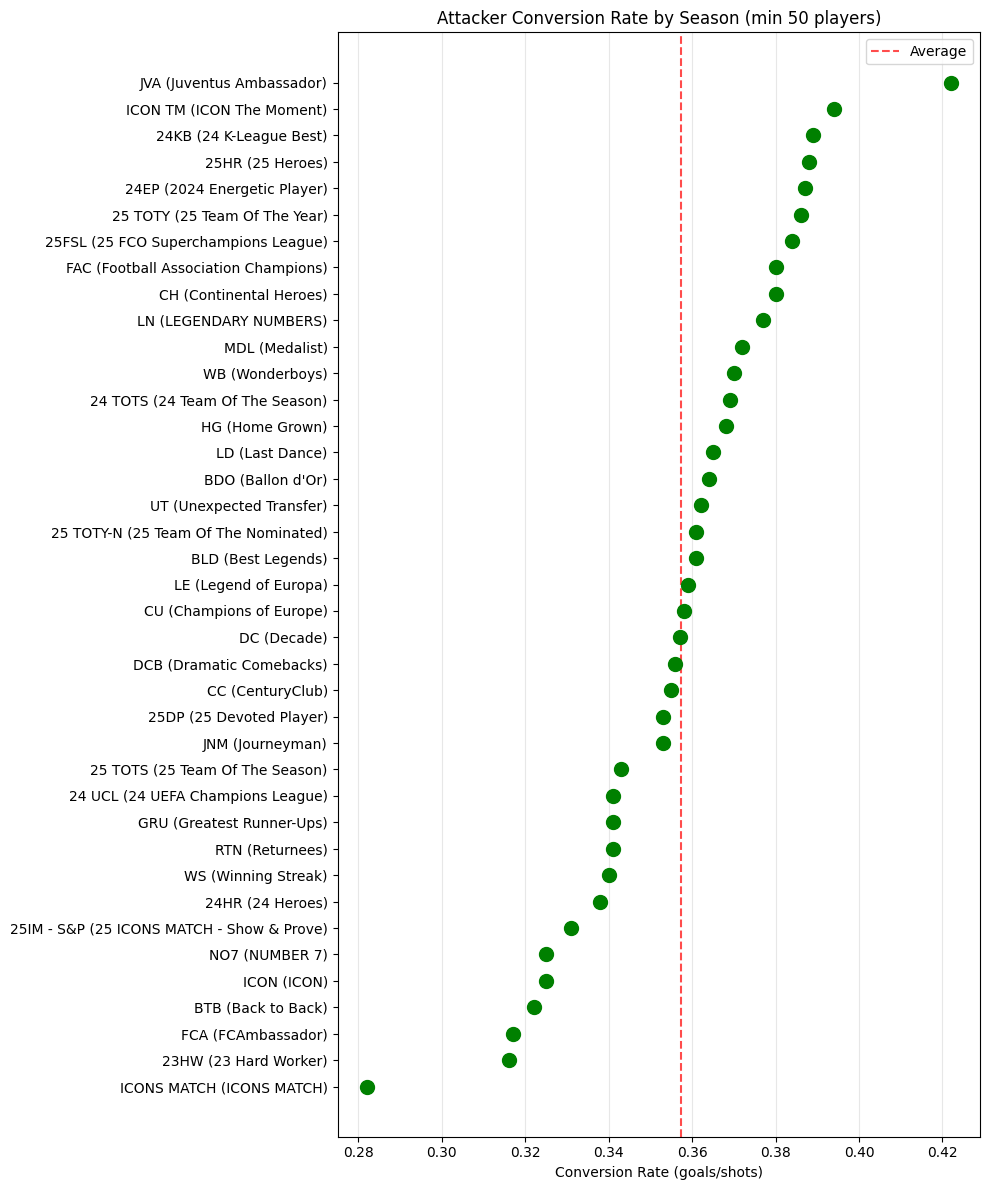

In [211]:
plt.figure(figsize=(10, 12))
plt.scatter(
    attacker_season_stats["conversion_rate"],
    attacker_season_stats["season_name"],
    color="green",
    s=100,
    zorder=3
)
plt.axvline(x=attacker_season_stats["conversion_rate"].mean(), 
            color="red", linestyle="--", alpha=0.7, label="Average")
plt.title("Attacker Conversion Rate by Season (min 50 players)")
plt.xlabel("Conversion Rate (goals/shots)")
plt.grid(axis="x", alpha=0.3)
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [212]:
# conversion rate by season for MIDFIELDERS only
midfielder_season_stats = pd.read_sql("""
    SELECT 
        p.season_prefix,
        COUNT(*) AS total,
        SUM(p.goal) AS total_goals,
        SUM(p.shoot) AS total_shoots,
        ROUND(SUM(p.goal) * 1.0 / NULLIF(SUM(p.shoot), 0), 3) AS conversion_rate
    FROM players_view p
    WHERE p.position_group = 'Midfielder'
    AND p.shoot > 0
    GROUP BY p.season_prefix
    HAVING total >= 50                                
    ORDER BY conversion_rate DESC
""", conn)

midfielder_season_stats["season_name"] = midfielder_season_stats["season_prefix"].map(
    lambda x: season_map.get(x, str(x))
)

print(f"Total seasons with MIDFIELDER data: {len(midfielder_season_stats)}")
print(midfielder_season_stats[["season_prefix", "season_name", "total", 
                              "total_goals", "total_shoots", "conversion_rate"]].to_string(index=False))

Total seasons with MIDFIELDER data: 44
 season_prefix                                season_name  total  total_goals  total_shoots  conversion_rate
           270                            SPL (Spotlight)     54           30            76            0.395
           807              24 TOTY (24 Team Of The Year)     58           40           109            0.367
           850       25FSL (25 FCO Superchampions League)     85           55           152            0.362
           256                         BTB (Back to Back)     81           43           123            0.350
           818                            LD (Last Dance)    202          107           320            0.334
           801                  JVA (Juventus Ambassador)    401          232           704            0.330
           831              25 TOTY (25 Team Of The Year)    187          113           354            0.319
           100                  ICON TM (ICON The Moment)    308          193           6

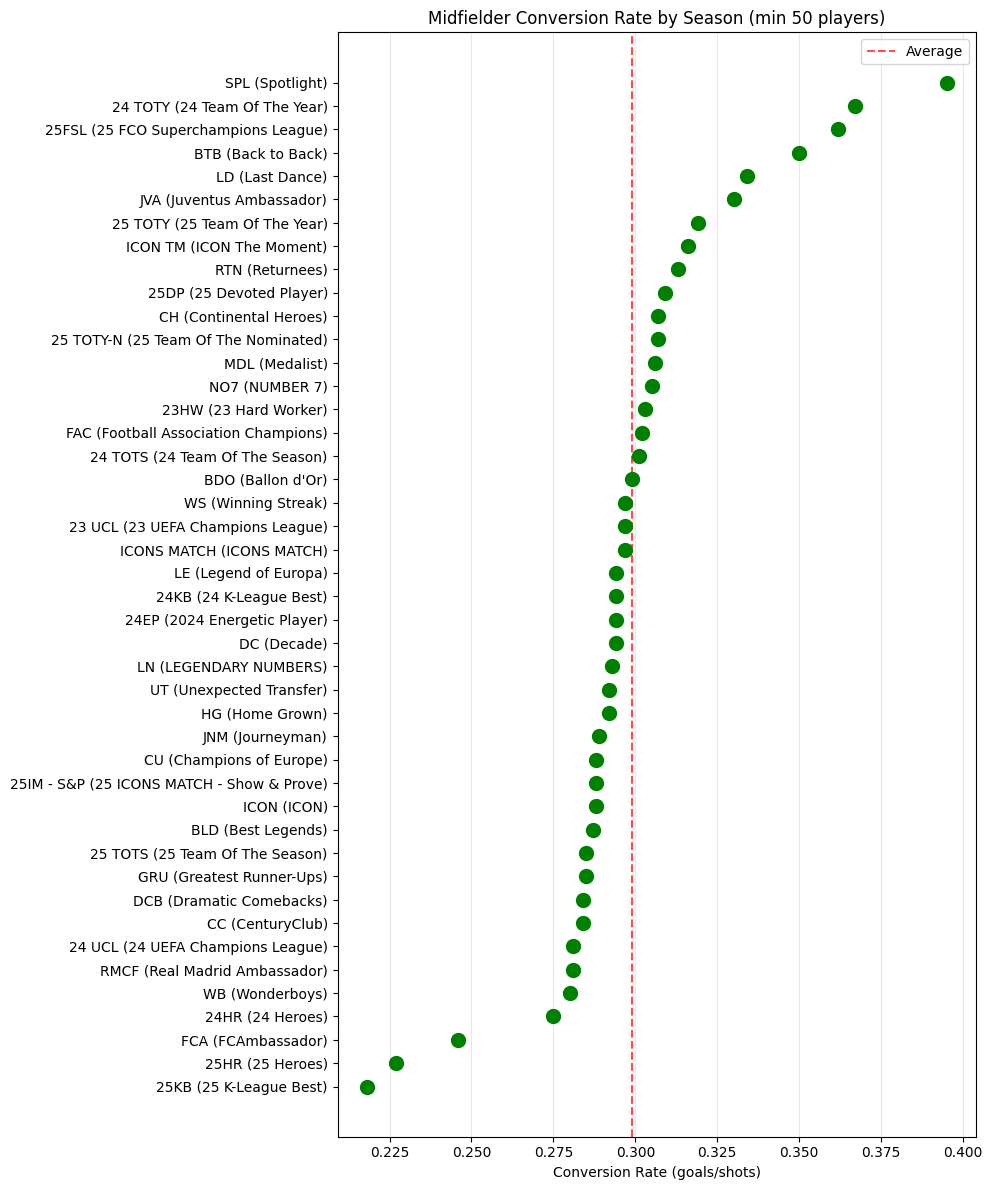

In [213]:
plt.figure(figsize=(10, 12))
plt.scatter(
    midfielder_season_stats["conversion_rate"],
    midfielder_season_stats["season_name"],
    color="green",
    s=100,
    zorder=3
)
plt.axvline(x=midfielder_season_stats["conversion_rate"].mean(), 
            color="red", linestyle="--", alpha=0.7, label="Average")
plt.title("Midfielder Conversion Rate by Season (min 50 players)")
plt.xlabel("Conversion Rate (goals/shots)")
plt.grid(axis="x", alpha=0.3)
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [214]:
# conversion rate by season for DEFENDER only
defender_season_stats = pd.read_sql("""
    SELECT 
        p.season_prefix,
        COUNT(*) AS total,
        SUM(p.goal) AS total_goals,
        SUM(p.shoot) AS total_shoots,
        ROUND(SUM(p.goal) * 1.0 / NULLIF(SUM(p.shoot), 0), 3) AS conversion_rate
    FROM players_view p
    WHERE p.position_group = 'Defender'
    AND p.shoot > 0
    GROUP BY p.season_prefix
    HAVING total >= 50                                
    ORDER BY conversion_rate DESC
""", conn)

defender_season_stats["season_name"] = defender_season_stats["season_prefix"].map(
    lambda x: season_map.get(x, str(x))
)

print(f"Total seasons with DEFENDER data: {len(defender_season_stats)}")
print(defender_season_stats[["season_prefix", "season_name", "total", 
                              "total_goals", "total_shoots", "conversion_rate"]].to_string(index=False))

Total seasons with DEFENDER data: 20
 season_prefix                       season_name  total  total_goals  total_shoots  conversion_rate
           101                       ICON (ICON)     87           27           105            0.257
           814          UT (Unexpected Transfer)    298           81           339            0.239
           836                   WB (Wonderboys)    271           74           318            0.233
           825          CU (Champions of Europe)    703          189           811            0.233
           826      24EP (2024 Energetic Player)    242           63           274            0.230
           828                BLD (Best Legends)     59           17            76            0.224
           802                       DC (Decade)    368           93           416            0.224
           283                   HG (Home Grown)     78           19            85            0.224
           840             LE (Legend of Europa)    432        

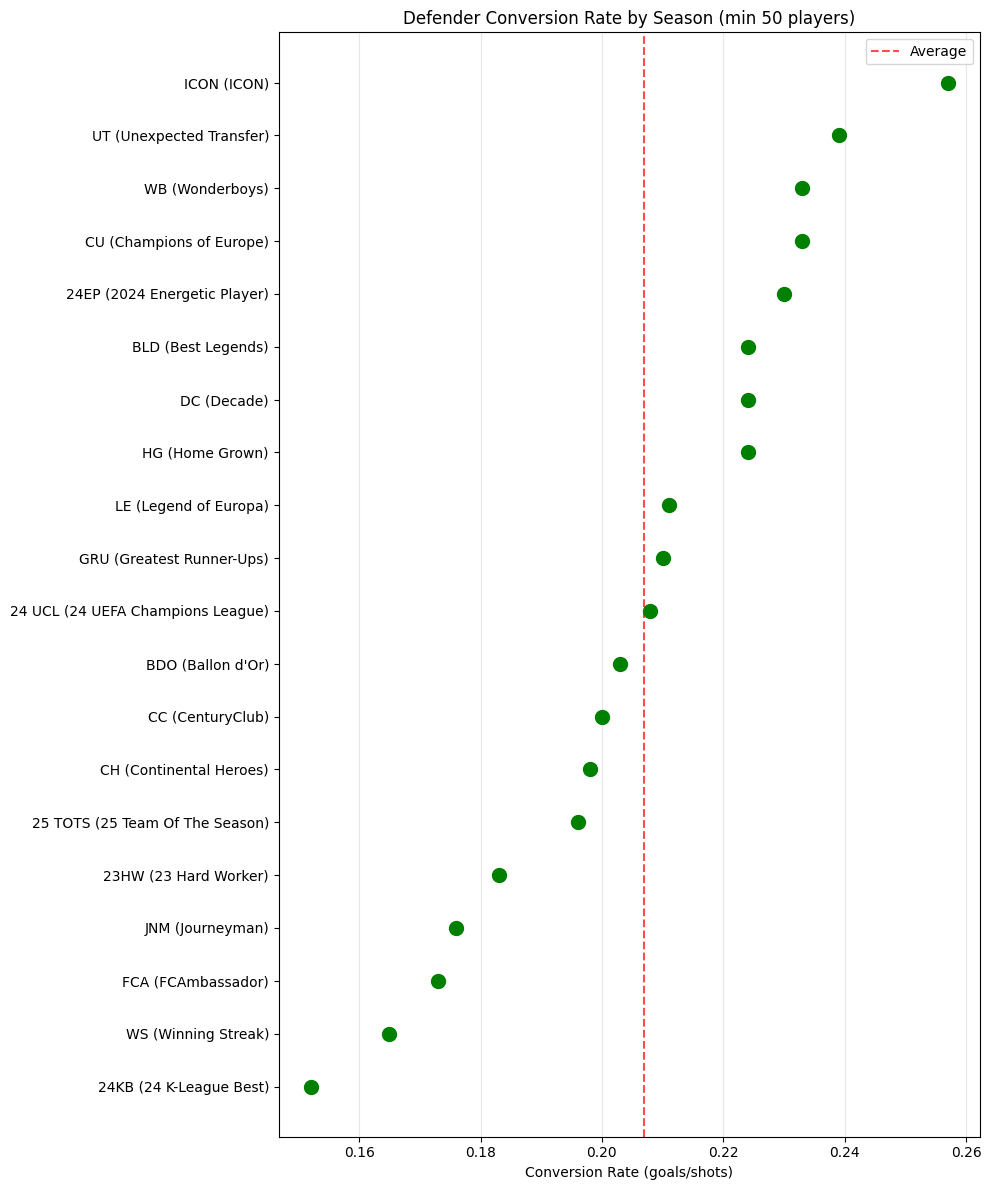

In [215]:
plt.figure(figsize=(10, 12))
plt.scatter(
    defender_season_stats["conversion_rate"],
    defender_season_stats["season_name"],
    color="green",
    s=100,
    zorder=3
)
plt.axvline(x=defender_season_stats["conversion_rate"].mean(), 
            color="red", linestyle="--", alpha=0.7, label="Average")
plt.title("Defender Conversion Rate by Season (min 50 players)")
plt.xlabel("Conversion Rate (goals/shots)")
plt.grid(axis="x", alpha=0.3)
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Player Performance Analysis

In [216]:
# players with 200+ appearances in a single season (active only - must have effective/shoot or goal)
player_in_season_2 = pd.read_sql("""
    SELECT 
        player_id,
        season_prefix,
        COUNT(*) AS appearances,
        SUM(shoot) AS total_shoots,
        SUM(goal) AS total_goals
    FROM players
    WHERE shoot > 0 OR goal > 0 OR effective_shoot > 0
    GROUP BY player_id, season_prefix
    HAVING appearances >= 200
    ORDER BY appearances DESC
""", conn)

player_in_season_2["season_name"] = player_in_season_2["season_prefix"].map(
    lambda x: season_map.get(x, str(x))
)

print(f"Player-season combinations with 200+ appearances (active): {len(player_in_season_2)}")
print(player_in_season_2[["player_id", "season_name", "appearances", 
                                  "total_shoots", "total_goals"]].to_string(index=False))

Player-season combinations with 200+ appearances (active): 6
player_id                     season_name  appearances  total_shoots  total_goals
   231747                 WB (Wonderboys)          288           654          247
   214100                 RTN (Returnees)          242           541          185
   231747   25 TOTY (25 Team Of The Year)          236           567          226
   004000                     DC (Decade)          222           506          177
   231443 25 TOTS (25 Team Of The Season)          214           377          132
   165153                     DC (Decade)          202           496          168


In [217]:
# deep dive into player 231747
player_231747 = pd.read_sql("""
    SELECT 
        p.season_prefix,
        COUNT(*) AS appearances,
        SUM(p.shoot) AS total_shoots,
        SUM(p.goal) AS total_goals,
        ROUND(AVG(p.goal), 4) AS avg_goals,
        ROUND(SUM(p.goal) * 1.0 / NULLIF(SUM(p.shoot), 0), 3) AS conversion_rate,
        ROUND(AVG(p.sp_rating), 3) AS avg_rating
    FROM players p
    WHERE p.player_id = '231747'
    AND (p.shoot > 0 OR p.goal > 0)
    GROUP BY p.season_prefix
    ORDER BY appearances DESC
""", conn)

player_231747["season_name"] = player_231747["season_prefix"].map(
    lambda x: season_map.get(x, str(x))
)

print(player_231747[["season_prefix", "season_name", "appearances", "total_shoots", 
                       "total_goals", "avg_goals", "conversion_rate", 
                       "avg_rating"]].to_string(index=False))

 season_prefix                       season_name  appearances  total_shoots  total_goals  avg_goals  conversion_rate  avg_rating
           836                   WB (Wonderboys)          288           654          247     0.8576            0.378       7.736
           831     25 TOTY (25 Team Of The Year)          236           567          226     0.9576            0.399       7.821
           814          UT (Unexpected Transfer)           97           235           84     0.8660            0.357       7.645
           828                BLD (Best Legends)           69           173           73     1.0580            0.422       7.972
           834 24 UCL (24 UEFA Champions League)           38            95           34     0.8947            0.358       7.892
           844   25 TOTS (25 Team Of The Season)           34            86           43     1.2647            0.500       7.844
           820   24 TOTS (24 Team Of The Season)           21            46           20     0.95

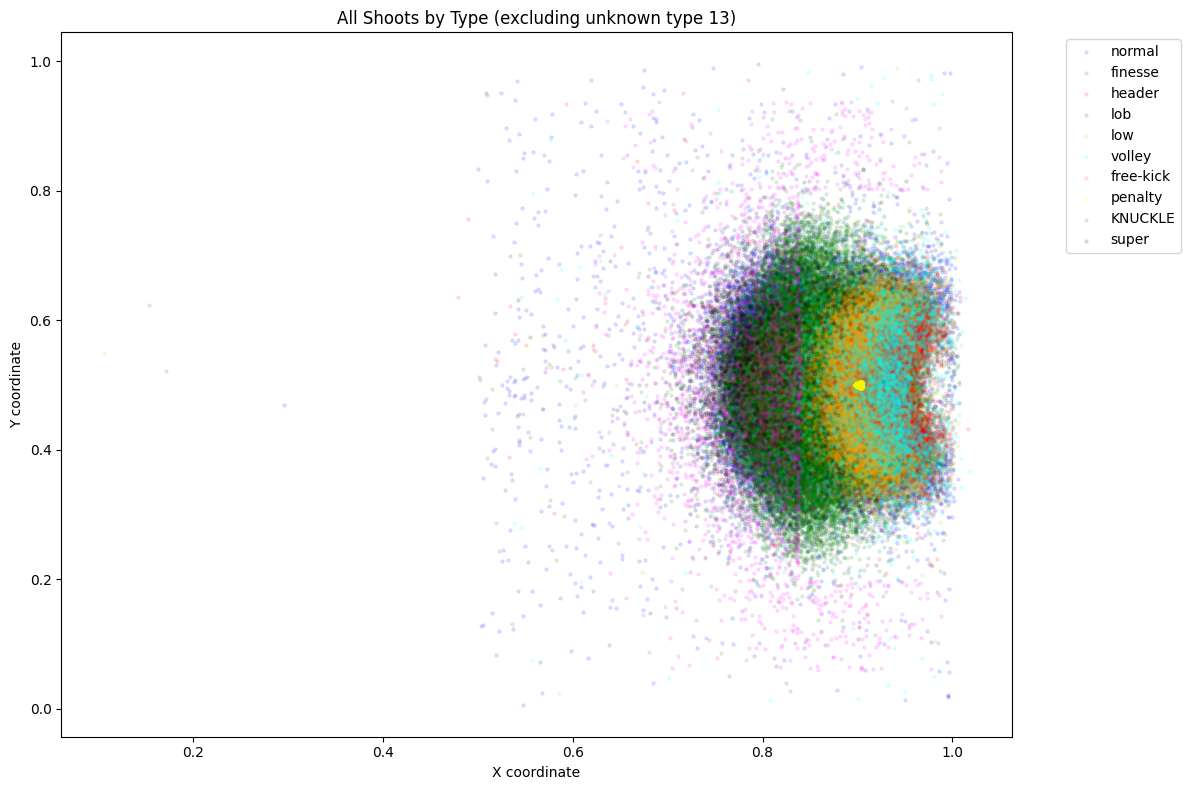

In [218]:
# all shoots colored by type (excluding type 13)
all_shoots_typed = pd.read_sql("""
    SELECT x, y, type
    FROM shoot_details
    WHERE type != 13
""", conn)

# TYPE_MAP = {
#     1: "normal", 2: "finesse", 3: "header", 4: "lob",
#     5: "flare", 6: "low", 7: "volley", 8: "free-kick",
#     9: "penalty", 10: "KNUCKLE", 11: "BICYCLE", 12: "super"
# }

colors = {
    1: "blue", 2: "green", 3: "red", 4: "purple",
    6: "orange", 7: "cyan", 8: "magenta",
    9: "yellow", 10: "brown", 12: "black"
}

fig, ax = plt.subplots(figsize=(12, 8))

for shot_type, group in all_shoots_typed.groupby("type"):
    ax.scatter(
        group["x"], group["y"],
        c=colors.get(shot_type, "gray"),
        label=TYPE_MAP.get(shot_type, str(shot_type)),
        alpha=0.1,
        s=5
    )

ax.set_title("All Shoots by Type (excluding unknown type 13)")
ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")
ax.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")
plt.tight_layout()
plt.show()

Close range goals: 4556
Y range: 0.0189 - 0.9814
Avg Y: 0.4988


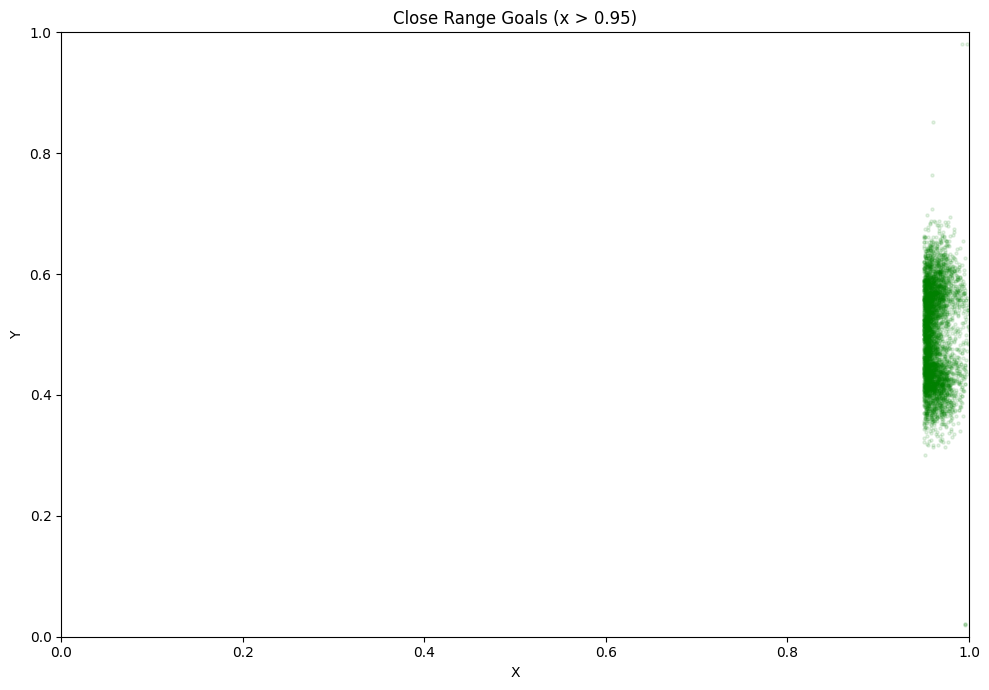

In [219]:
close_goals = pd.read_sql("""
    SELECT x, y
    FROM shoot_details
    WHERE result = 3
    AND x > 0.95
""", conn)

print(f"Close range goals: {len(close_goals)}")
print(f"Y range: {close_goals['y'].min():.4f} - {close_goals['y'].max():.4f}")
print(f"Avg Y: {close_goals['y'].mean():.4f}")

plt.figure(figsize=(10, 7))
plt.scatter(close_goals["x"], close_goals["y"], alpha=0.1, s=5, c="green")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("Close Range Goals (x > 0.95)")
plt.xlabel("X")
plt.ylabel("Y")
plt.tight_layout()
plt.show()

In [220]:
player_231747_wb = pd.read_sql("""
    SELECT 
        p.sp_position,
        p.sp_grade,
        COUNT(*) AS appearances,
        SUM(p.shoot) AS total_shoots,
        SUM(p.goal) AS total_goals,
        ROUND(AVG(p.goal), 4) AS avg_goals,
        ROUND(SUM(p.goal) * 1.0 / NULLIF(SUM(p.shoot), 0), 3) AS conversion_rate,
        ROUND(AVG(p.sp_rating), 3) AS avg_rating
    FROM players p
    WHERE p.player_id = '231747'
    AND p.season_prefix = 836
    GROUP BY p.sp_position, p.sp_grade
    ORDER BY appearances DESC
""", conn)

player_231747_wb["position_name"] = player_231747_wb["sp_position"].map(
    lambda x: position_map.get(x, str(x))
)

print("Player 231747 in WB (Wonderboys) — by position and grade:")
print(player_231747_wb[["position_name", "sp_grade", "appearances", "sp_position",
                          "total_shoots", "total_goals",
                          "avg_goals", "conversion_rate", 
                          "avg_rating"]].to_string(index=False))

Player 231747 in WB (Wonderboys) — by position and grade:
position_name  sp_grade  appearances  sp_position  total_shoots  total_goals  avg_goals  conversion_rate  avg_rating
           ST         5           98           25           211           75     0.7653            0.355       7.683
           ST         6           35           25            65           23     0.6571            0.354       7.457
          SUB         5           34           28             7            3     0.0882            0.429       1.397
           ST         8           20           25            46           19     0.9500            0.413       8.110
           LW         5           18           27            18            5     0.2778            0.278       7.011
           RW         5           17           23             9            2     0.1176            0.222       6.724
           LS         5           14           26            39           13     0.9286            0.333       8.179
      

In [221]:
mbappe_wb_shoots = pd.read_sql("""
    SELECT 
        sd.x,
        sd.y,
        sd.result,
        sd.type,
        sd.in_penalty
    FROM shoot_details sd
    JOIN players p 
        ON sd.match_id = p.match_id 
        AND sd.ouid = p.ouid
        AND sd.sp_id = p.sp_id
    WHERE p.player_id = '231747'
    AND p.season_prefix = 836
""", conn)

print(f"Total shoots by Mbappe in WB: {len(mbappe_wb_shoots)}")
print(f"Goals:      {(mbappe_wb_shoots['result'] == 3).sum()}")
print(f"On target:  {(mbappe_wb_shoots['result'] == 1).sum()}")
print(f"Off target: {(mbappe_wb_shoots['result'] == 2).sum()}")
print(f"\nX range: {mbappe_wb_shoots['x'].min():.3f} - {mbappe_wb_shoots['x'].max():.3f}")
print(f"Y range: {mbappe_wb_shoots['y'].min():.3f} - {mbappe_wb_shoots['y'].max():.3f}")

Total shoots by Mbappe in WB: 674
Goals:      247
On target:  276
Off target: 151

X range: 0.543 - 0.992
Y range: 0.040 - 0.807


In [222]:
# compare WB vs 25 TOTY conversion rates by result
for season_prefix, season_name in [(836, "WB"), (831, "25 TOTY")]:
    shoots = pd.read_sql(f"""
        SELECT md.result,
               COUNT(*) AS total_shots,
               SUM(CASE WHEN sd.result = 3 THEN 1 ELSE 0 END) AS goals,
               ROUND(SUM(CASE WHEN sd.result = 3 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS conversion
        FROM shoot_details sd
        JOIN players p 
            ON sd.match_id = p.match_id 
            AND sd.ouid = p.ouid
            AND sd.sp_id = p.sp_id
        JOIN match_details md
            ON sd.match_id = md.match_id
            AND sd.ouid = md.ouid
        WHERE p.player_id = '231747'
        AND p.season_prefix = {season_prefix}
        GROUP BY md.result
        ORDER BY md.result
    """, conn)

    print(f"\nMbappé {season_name}:")
    print(shoots.to_string(index=False))


Mbappé WB:
result  total_shots  goals  conversion
  draw           88     34        38.6
  loss          219     68        31.1
   win          367    145        39.5

Mbappé 25 TOTY:
result  total_shots  goals  conversion
  draw          111     31        27.9
  loss          214     65        30.4
   win          257    130        50.6


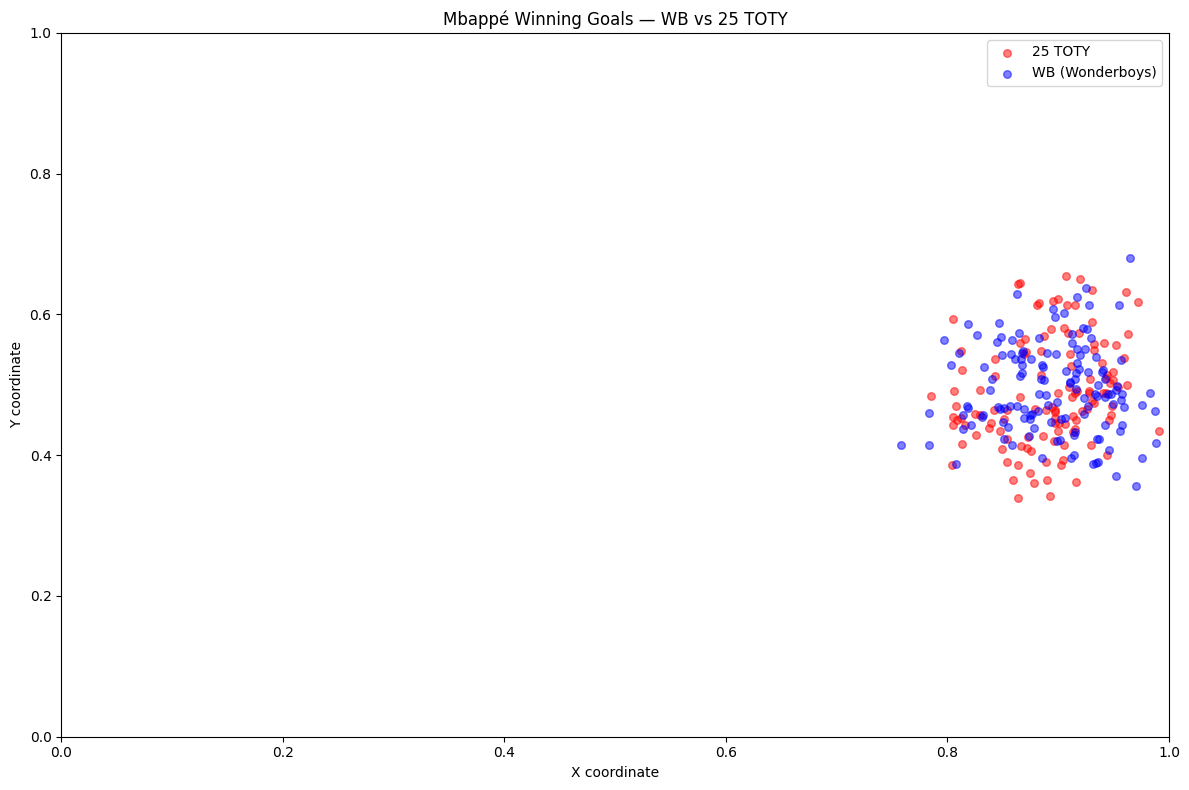

In [223]:
mbappe_win_goals_seasons = pd.read_sql("""
    SELECT 
        sd.x,
        sd.y,
        p.season_prefix
    FROM shoot_details sd
    JOIN players p 
        ON sd.match_id = p.match_id 
        AND sd.ouid = p.ouid
        AND sd.sp_id = p.sp_id
    JOIN match_details md
        ON sd.match_id = md.match_id
        AND sd.ouid = md.ouid
    WHERE p.player_id = '231747'
    AND p.season_prefix IN (836, 831)
    AND sd.result = 3
    AND md.result = 'win'
    AND sd.type != 9
""", conn)

season_colors = {836: "blue", 831: "red"}
season_labels = {836: "WB (Wonderboys)", 831: "25 TOTY"}

fig, ax = plt.subplots(figsize=(12, 8))

for season, group in mbappe_win_goals_seasons.groupby("season_prefix"):
    ax.scatter(
        group["x"], group["y"],
        c=season_colors.get(season, "gray"),
        label=season_labels.get(season, str(season)),
        alpha=0.5,
        s=30
    )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Mbappé Winning Goals — WB vs 25 TOTY")
ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")
ax.legend()
plt.tight_layout()
plt.show()

In [224]:
def decode_goal_time(goal_time):
    threshold = 2 ** 24
    if goal_time < threshold * 1:
        return "1st Half", goal_time
    elif goal_time < threshold * 2:
        return "2nd Half", goal_time - threshold * 1 + 45 * 60
    elif goal_time < threshold * 3:
        return "Extra 1st", goal_time - threshold * 2 + 90 * 60
    elif goal_time < threshold * 4:
        return "Extra 2nd", goal_time - threshold * 3 + 105 * 60
    else:
        return "Penalty Shootout", goal_time - threshold * 4 + 120 * 60

# print(decode_goal_time(786))
# print(decode_goal_time(16777864))

mbappe_win_goals_seasons_2 = pd.read_sql("""
    SELECT 
        sd.x,
        sd.y,
        sd.goal_time,
        p.season_prefix
    FROM shoot_details sd
    JOIN players p 
        ON sd.match_id = p.match_id 
        AND sd.ouid = p.ouid
        AND sd.sp_id = p.sp_id
    JOIN match_details md
        ON sd.match_id = md.match_id
        AND sd.ouid = md.ouid
    WHERE p.player_id = '231747'
    AND p.season_prefix IN (836, 831)
    AND sd.result = 3
    AND md.result = 'win'
    AND sd.type != 9
""", conn)

# decode goal time
mbappe_win_goals_seasons_2["period"] = mbappe_win_goals_seasons_2["goal_time"].apply(
    lambda x: decode_goal_time(x)[0]
)

print(mbappe_win_goals_seasons_2["period"].value_counts())

period
2nd Half     130
1st Half     124
Extra 2nd      1
Extra 1st      1
Name: count, dtype: int64


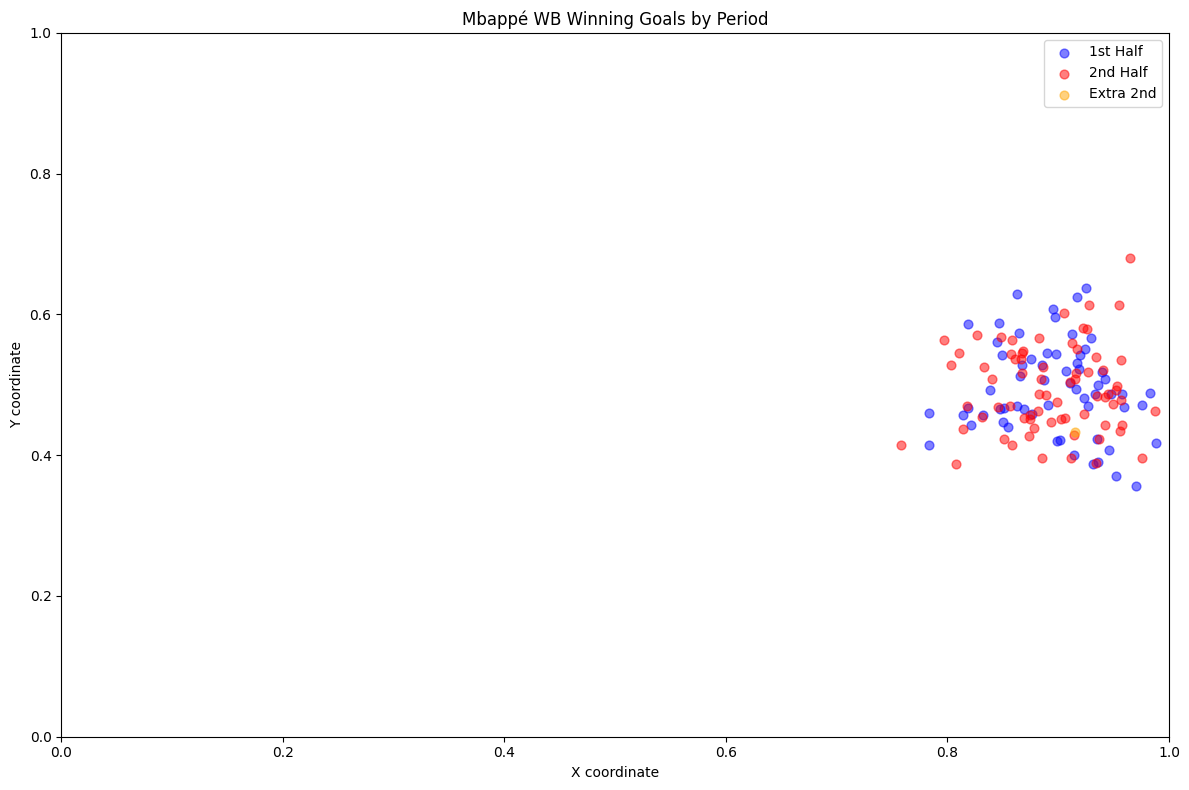

In [225]:
mbappe_wb_goals = pd.read_sql("""
    SELECT 
        sd.x,
        sd.y,
        sd.goal_time,
        p.season_prefix
    FROM shoot_details sd
    JOIN players p 
        ON sd.match_id = p.match_id 
        AND sd.ouid = p.ouid
        AND sd.sp_id = p.sp_id
    JOIN match_details md
        ON sd.match_id = md.match_id
        AND sd.ouid = md.ouid
    WHERE p.player_id = '231747'
    AND p.season_prefix = 836
    AND sd.result = 3
    AND md.result = 'win'
    AND sd.type != 9
""", conn)

mbappe_wb_goals["period"] = mbappe_wb_goals["goal_time"].apply(
    lambda x: decode_goal_time(x)[0]
)

period_colors = {
    "1st Half": "blue",
    "2nd Half": "red",
    "Extra 1st": "green",
    "Extra 2nd": "orange",
    "Penalty Shootout": "purple"
}

fig, ax = plt.subplots(figsize=(12, 8))

for period, group in mbappe_wb_goals.groupby("period"):
    ax.scatter(
        group["x"], group["y"],
        c=period_colors.get(period, "gray"),
        label=period,
        alpha=0.5,
        s=40
    )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Mbappé WB Winning Goals by Period")
ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")
ax.legend()
plt.tight_layout()
plt.show()

In [226]:
mbappe_wb_goals_full = pd.read_sql("""
    SELECT 
        sd.x,
        sd.y,
        sd.type,
        sd.goal_time
    FROM shoot_details sd
    JOIN players p 
        ON sd.match_id = p.match_id 
        AND sd.ouid = p.ouid
        AND sd.sp_id = p.sp_id
    JOIN match_details md
        ON sd.match_id = md.match_id
        AND sd.ouid = md.ouid
    WHERE p.player_id = '231747'
    AND p.season_prefix = 836
    AND sd.result = 3
    AND md.result = 'win'
""", conn)

mbappe_wb_goals_full["type_name"] = mbappe_wb_goals_full["type"].map(
    lambda x: TYPE_MAP.get(x, str(x))
)
mbappe_wb_goals_full["period"] = mbappe_wb_goals_full["goal_time"].apply(
    lambda x: decode_goal_time(x)[0]
)

print(f"Total: {len(mbappe_wb_goals_full)}")
print(mbappe_wb_goals_full["type_name"].value_counts().to_string())

Total: 145
type_name
finesse    66
low        22
normal     17
volley     13
header     12
penalty    11
lob         2
13          2


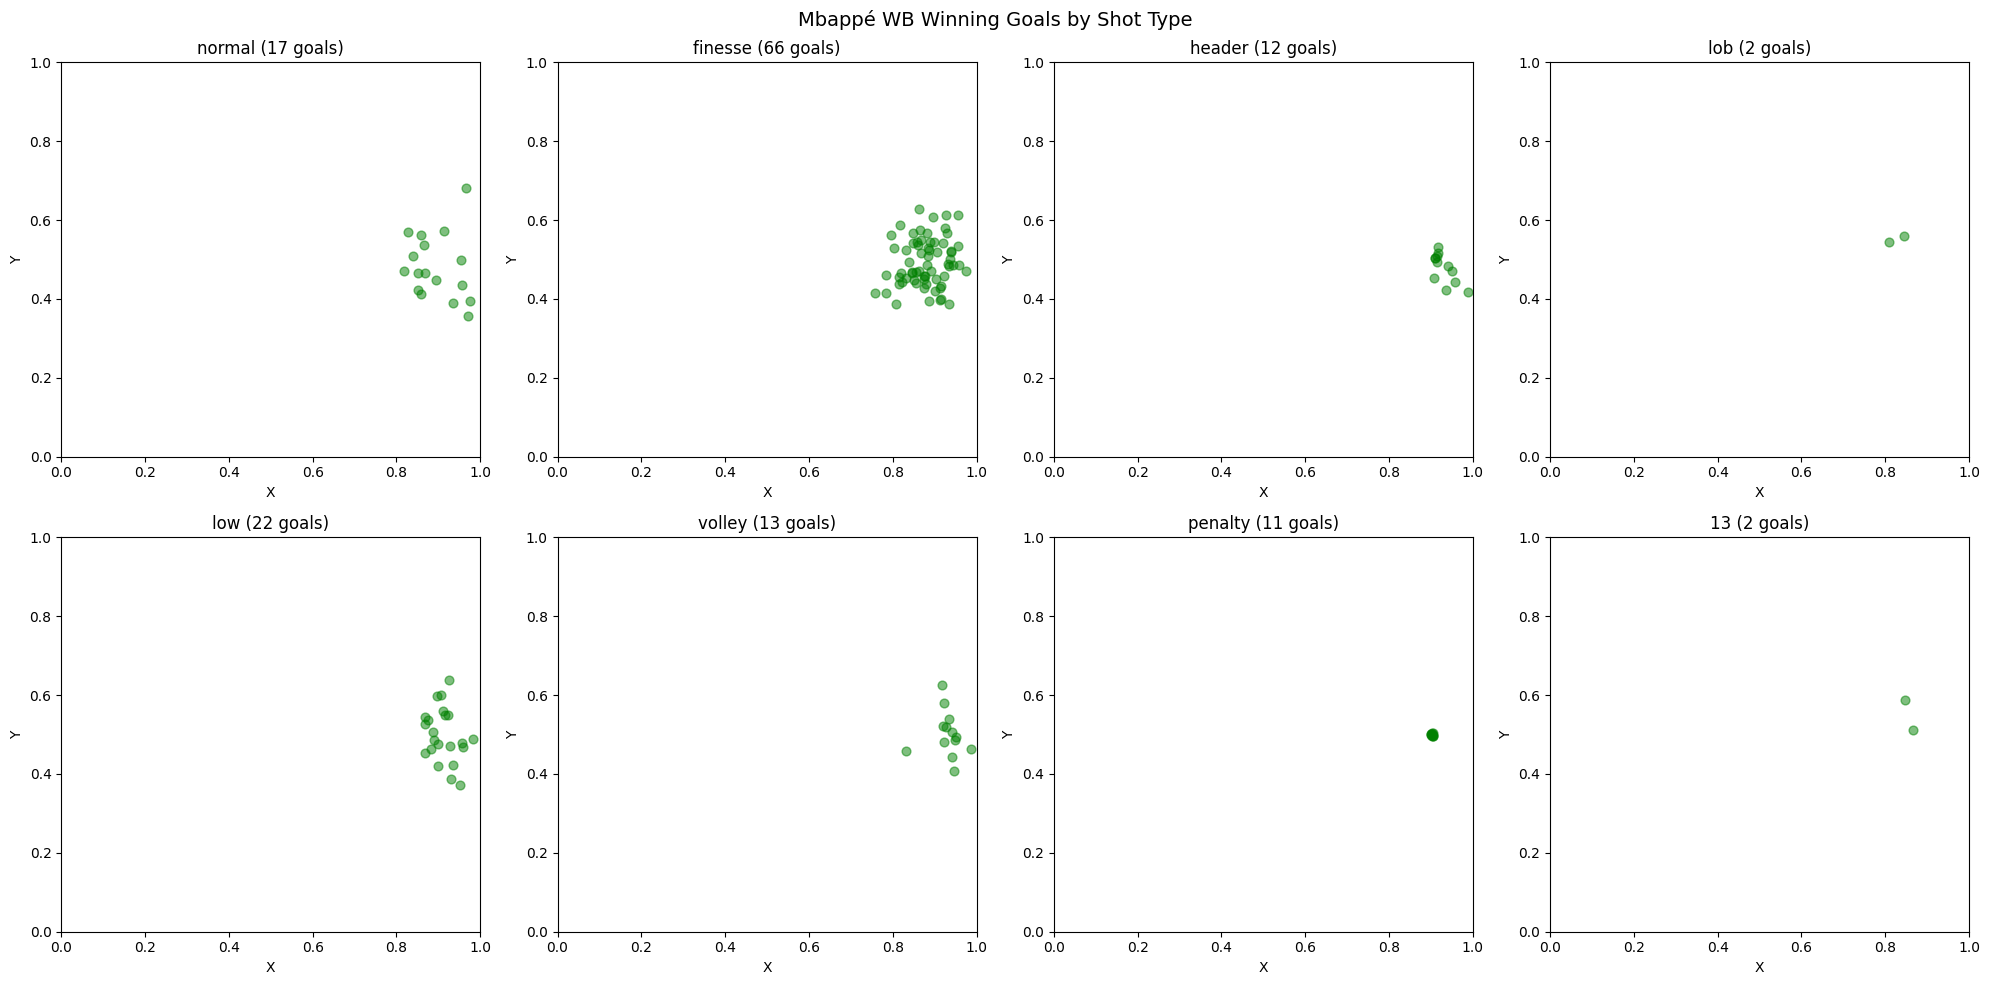

In [227]:
shot_types = mbappe_wb_goals_full["type"].unique()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, shot_type in enumerate(sorted(shot_types)):
    subset = mbappe_wb_goals_full[mbappe_wb_goals_full["type"] == shot_type]
    ax = axes[i]
    ax.scatter(subset["x"], subset["y"], alpha=0.5, s=40, c="green")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f"{TYPE_MAP.get(shot_type, str(shot_type))} ({len(subset)} goals)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

for j in range(len(shot_types), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Mbappé WB Winning Goals by Shot Type", fontsize=14)
plt.tight_layout()
plt.show()

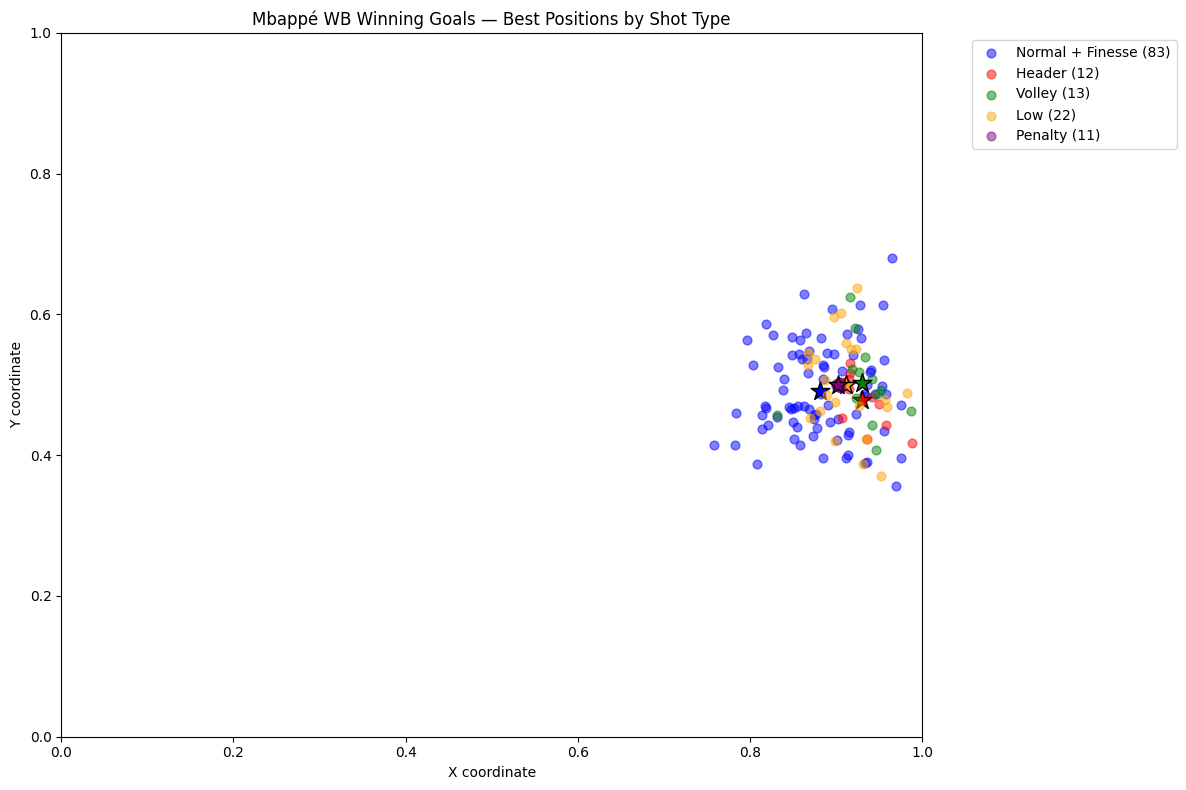

In [ ]:
groups = {
    "Normal + Finesse": [1, 2],
    "Header":           [3],
    "Volley":           [7],
    "Low":              [6],
    "Penalty":          [9]
}

group_colors = {
    "Normal + Finesse": "blue",
    "Header":           "red",
    "Volley":           "green",
    "Low":              "orange",
    "Penalty":          "purple"
}

fig, ax = plt.subplots(figsize=(12, 8))

for group_name, types in groups.items():
    subset = mbappe_wb_goals_full[mbappe_wb_goals_full["type"].isin(types)]
    if len(subset) == 0:
        continue
    
    # plot dots
    ax.scatter(subset["x"], subset["y"],
               c=group_colors[group_name],
               label=f"{group_name} ({len(subset)})",
               alpha=0.5, s=40)
    
    # add mean point (larger dot)
    ax.scatter(subset["x"].mean(), subset["y"].mean(),
               c=group_colors[group_name],
               s=200, marker="*", edgecolors="black", linewidths=1)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Mbappé WB Winning Goals — Best Positions by Shot Type")
ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()